In [6]:
# ============================================================
# 1. IMPORTS
# ============================================================

from pathlib import Path
import sys
import importlib
import sqlite3

import pandas as pd
import numpy as np

from sklearn.metrics import mean_squared_error, mean_squared_log_error, r2_score

# Models
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

In [7]:
# ============================================================
# 2. PROJECT PATH
# ============================================================

project_root = Path(r"C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg")

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import src.data_pipeline
import src.events

importlib.reload(src.data_pipeline)
importlib.reload(src.events)

from src.data_pipeline import ModelDatasetBuilder
from src.events import SimpleEventDetector, CombinedEventDetector

In [9]:
# ============================================================
# 3. PATHS
# ============================================================

db_path = project_root / "NordPoool" / "data" / "thesis_database.db"

rbatheta_2020_events_path = Path(
    r"C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\rbaTheta\simulations\all_tests_together\NO1_2020_rbatheta_event_hours.csv"
)

print("DB exists:", db_path.exists())
print("DB path:", db_path)

print("RBA-Theta 2020 exists:", rbatheta_2020_events_path.exists())
print("RBA-Theta 2020 path:", rbatheta_2020_events_path)

DB exists: True
DB path: C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\NordPoool\data\thesis_database.db
RBA-Theta 2020 exists: True
RBA-Theta 2020 path: C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\rbaTheta\simulations\all_tests_together\NO1_2020_rbatheta_event_hours.csv


In [10]:
# ============================================================
# 4. EXPERIMENT CONFIGURATION
# ============================================================

zone_code = "NO1"

train_start = "2020-01-01"
train_end = "2020-12-31"

test_start = "2021-04-10"
test_end = "2021-04-16"

target_horizon = 1

print("Zone:", zone_code)
print("Train period:", train_start, "to", train_end)
print("Test period:", test_start, "to", test_end)
print("Target horizon:", target_horizon)

Zone: NO1
Train period: 2020-01-01 to 2020-12-31
Test period: 2021-04-10 to 2021-04-16
Target horizon: 1


In [11]:
# ============================================================
# 5. LOAD TRAIN + TEST PRICES FROM DATABASE
# ============================================================

conn = sqlite3.connect(db_path)

query = """
SELECT 
    p.price_id,
    p.zone_id,
    bz.zone_code,
    p.delivery_day,
    p.hour,
    p.price_value
FROM Prices p
JOIN BiddingZones bz 
    ON p.zone_id = bz.zone_id
WHERE bz.zone_code = ?
  AND (
        (p.delivery_day >= ? AND p.delivery_day <= ?)
        OR
        (p.delivery_day >= ? AND p.delivery_day <= ?)
      )
ORDER BY p.delivery_day, p.hour
"""

df_prices = pd.read_sql_query(
    query,
    conn,
    params=(zone_code, train_start, train_end, test_start, test_end)
)

conn.close()

print("Shape:", df_prices.shape)
print("Zones:", df_prices["zone_code"].unique())
print("Date range:", df_prices["delivery_day"].min(), "to", df_prices["delivery_day"].max())
print("Hour range:", df_prices["hour"].min(), "to", df_prices["hour"].max())

df_prices.head()

Shape: (8952, 6)
Zones: <StringArray>
['NO1']
Length: 1, dtype: str
Date range: 2020-01-01 to 2021-04-16
Hour range: 0 to 23


,price_id,zone_id,zone_code,delivery_day,hour,price_value
0,12,12,NO1,2020-01-01,0,31.82
1,32,12,NO1,2020-01-01,1,31.77
2,52,12,NO1,2020-01-01,2,31.57
3,72,12,NO1,2020-01-01,3,31.28
4,92,12,NO1,2020-01-01,4,30.72


In [12]:
# ============================================================
# 6. CREATE DATETIME AND TARGET WITHOUT LAGS
# ============================================================

df_model = df_prices.copy()

df_model["delivery_day"] = pd.to_datetime(df_model["delivery_day"])
df_model["hour"] = pd.to_numeric(df_model["hour"], errors="coerce")

df_model["datetime"] = (
    df_model["delivery_day"] + pd.to_timedelta(df_model["hour"], unit="h")
)

df_model = df_model.sort_values("datetime").reset_index(drop=True)

# ------------------------------------------------------------
# Target: price one hour ahead
# Important: use datetime merge, not shift(-1), because train
# and test periods are not continuous.
# ------------------------------------------------------------

target_df = df_model[["datetime", "price_value"]].copy()
target_df["datetime"] = target_df["datetime"] - pd.Timedelta(hours=target_horizon)
target_df = target_df.rename(columns={"price_value": "target_price_1h"})

df_model = df_model.merge(
    target_df,
    on="datetime",
    how="left"
)

# Time features
df_model["hour_of_day"] = df_model["datetime"].dt.hour
df_model["day_of_week"] = df_model["datetime"].dt.dayofweek
df_model["month"] = df_model["datetime"].dt.month

df_model = df_model.dropna(subset=["target_price_1h"]).copy()

print("Original price rows:", len(df_prices))
print("Model rows after target:", len(df_model))
print("Datetime range:", df_model["datetime"].min(), "to", df_model["datetime"].max())

df_model.head()

Original price rows: 8952
Model rows after target: 8950
Datetime range: 2020-01-01 00:00:00 to 2021-04-16 22:00:00


,price_id,zone_id,zone_code,delivery_day,hour,price_value,datetime,target_price_1h,hour_of_day,day_of_week,month
0,12,12,NO1,2020-01-01,0,31.82,2020-01-01 00:00:00,31.77,0,2,1
1,32,12,NO1,2020-01-01,1,31.77,2020-01-01 01:00:00,31.57,1,2,1
2,52,12,NO1,2020-01-01,2,31.57,2020-01-01 02:00:00,31.28,2,2,1
3,72,12,NO1,2020-01-01,3,31.28,2020-01-01 03:00:00,30.72,3,2,1
4,92,12,NO1,2020-01-01,4,30.72,2020-01-01 04:00:00,30.27,4,2,1


In [13]:
# ============================================================
# 7. SPLIT FULL DATASET INTO TRAIN AND TEST
# ============================================================

train_start_ts = pd.Timestamp(train_start)
train_end_ts = pd.Timestamp(train_end + " 23:00:00")

test_start_ts = pd.Timestamp(test_start)
test_end_ts = pd.Timestamp(test_end + " 23:00:00")

df_train_full = df_model[
    (df_model["datetime"] >= train_start_ts) &
    (df_model["datetime"] <= train_end_ts)
].copy()

df_test_common = df_model[
    (df_model["datetime"] >= test_start_ts) &
    (df_model["datetime"] <= test_end_ts)
].copy()

print("Full train rows:", len(df_train_full))
print("Full train range:", df_train_full["datetime"].min(), "to", df_train_full["datetime"].max())

print("Common test rows:", len(df_test_common))
print("Common test range:", df_test_common["datetime"].min(), "to", df_test_common["datetime"].max())

Full train rows: 8783
Full train range: 2020-01-01 00:00:00 to 2020-12-31 22:00:00
Common test rows: 167
Common test range: 2021-04-10 00:00:00 to 2021-04-16 22:00:00


In [14]:
# ============================================================
# 8. LOAD RBATHETA 2020 EVENT HOURS
# ============================================================

df_rba_2020 = pd.read_csv(rbatheta_2020_events_path)
df_rba_2020["datetime"] = pd.to_datetime(df_rba_2020["datetime"])

print("RBA 2020 rows:", len(df_rba_2020))
print("RBA 2020 range:", df_rba_2020["datetime"].min(), "to", df_rba_2020["datetime"].max())
print()
print(df_rba_2020["rbatheta_event_type"].value_counts())

df_rba_2020.head()

RBA 2020 rows: 1434
RBA 2020 range: 2020-01-01 03:00:00 to 2020-12-31 22:00:00

rbatheta_event_type
stationary                1363
significant                 65
significant+stationary       6
Name: count, dtype: int64


,datetime,value,zone_code,rbatheta_event,rbatheta_event_type
0,2020-01-01 03:00:00,31.28,NO1,1,stationary
1,2020-01-01 04:00:00,30.72,NO1,1,stationary
2,2020-01-01 05:00:00,30.27,NO1,1,stationary
3,2020-01-01 06:00:00,30.17,NO1,1,stationary
4,2020-01-01 07:00:00,30.14,NO1,1,stationary


In [15]:
# ============================================================
# 9. BUILD RBATHETA TRAIN DATASET
# ============================================================

rba_train_times = df_rba_2020["datetime"].drop_duplicates()

df_train_rbatheta = df_train_full[
    df_train_full["datetime"].isin(rba_train_times)
].copy()

print("Full train rows:", len(df_train_full))
print("RBA-Theta train rows:", len(df_train_rbatheta))
print("Percentage of train data used:", len(df_train_rbatheta) / len(df_train_full) * 100)

print("RBA-Theta train range:", df_train_rbatheta["datetime"].min(), "to", df_train_rbatheta["datetime"].max())

df_train_rbatheta.head()

Full train rows: 8783
RBA-Theta train rows: 1434
Percentage of train data used: 16.326995331891155
RBA-Theta train range: 2020-01-01 03:00:00 to 2020-12-31 22:00:00


,price_id,zone_id,zone_code,delivery_day,hour,price_value,datetime,target_price_1h,hour_of_day,day_of_week,month
3,72,12,NO1,2020-01-01,3,31.28,2020-01-01 03:00:00,30.72,3,2,1
4,92,12,NO1,2020-01-01,4,30.72,2020-01-01 04:00:00,30.27,4,2,1
5,112,12,NO1,2020-01-01,5,30.27,2020-01-01 05:00:00,30.17,5,2,1
6,132,12,NO1,2020-01-01,6,30.17,2020-01-01 06:00:00,30.14,6,2,1
7,152,12,NO1,2020-01-01,7,30.14,2020-01-01 07:00:00,30.49,7,2,1


In [16]:
# ============================================================
# 10. BUILD OWN EVENTS TRAIN DATASET
# ============================================================

detector = SimpleEventDetector()

df_train_own_all = detector.detect_price_events(df_train_full.copy())

own_event_cols = [
    "low_price",
    "high_price",
    "price_spike",
    "extreme_price",
    "rapid_price_change",
    "price_ramp_up",
    "price_ramp_down",
    "high_volatility",
]

own_event_cols = [col for col in own_event_cols if col in df_train_own_all.columns]

df_train_own_all["own_event"] = df_train_own_all[own_event_cols].any(axis=1)

df_train_own = df_train_own_all[df_train_own_all["own_event"]].copy()

print("Own event columns:", own_event_cols)
print("Full train rows:", len(df_train_full))
print("Own-event train rows:", len(df_train_own))
print("Percentage of train data used:", len(df_train_own) / len(df_train_full) * 100)

print()
print("Event counts:")
print(df_train_own_all[own_event_cols].sum().sort_values(ascending=False))

df_train_own.head()

Own event columns: ['low_price', 'high_price', 'price_spike', 'extreme_price', 'rapid_price_change', 'price_ramp_up', 'price_ramp_down', 'high_volatility']
Full train rows: 8783
Own-event train rows: 2872
Percentage of train data used: 32.699533189115336

Event counts:
high_price            879
high_volatility       878
low_price             864
price_spike           440
price_ramp_up         439
rapid_price_change    439
price_ramp_down       439
extreme_price          88
dtype: int64


,price_id,zone_id,zone_code,delivery_day,hour,price_value,datetime,target_price_1h,hour_of_day,day_of_week,...,rolling_volatility_24h,low_price,high_price,price_spike,extreme_price,rapid_price_change,price_ramp_up,price_ramp_down,high_volatility,own_event
0,12,12,NO1,2020-01-01,0,31.82,2020-01-01 00:00:00,31.77,0,2,...,NaN,False,True,True,True,False,False,False,False,True
1,32,12,NO1,2020-01-01,1,31.77,2020-01-01 01:00:00,31.57,1,2,...,NaN,False,True,True,True,False,False,False,False,True
2,52,12,NO1,2020-01-01,2,31.57,2020-01-01 02:00:00,31.28,2,2,...,NaN,False,True,True,True,False,False,False,False,True
3,72,12,NO1,2020-01-01,3,31.28,2020-01-01 03:00:00,30.72,3,2,...,NaN,False,True,True,True,False,False,False,False,True
4,92,12,NO1,2020-01-01,4,30.72,2020-01-01 04:00:00,30.27,4,2,...,NaN,False,True,True,True,False,False,False,False,True


In [18]:
# ============================================================
# 11. DEFINE TRAINING DATASETS AND COMMON TEST SET
# ============================================================

train_datasets = {
    "full_prices": df_train_full,
    "rbatheta_events": df_train_rbatheta,
    "own_events": df_train_own,
}

df_test = df_test_common.copy()

for name, train_data in train_datasets.items():
    print(name)
    print("Train rows:", len(train_data))
    print("Train range:", train_data["datetime"].min(), "to", train_data["datetime"].max())
    print()

print("Common test rows:", len(df_test))
print("Common test range:", df_test["datetime"].min(), "to", df_test["datetime"].max())

full_prices
Train rows: 8783
Train range: 2020-01-01 00:00:00 to 2020-12-31 22:00:00

rbatheta_events
Train rows: 1434
Train range: 2020-01-01 03:00:00 to 2020-12-31 22:00:00

own_events
Train rows: 2872
Train range: 2020-01-01 00:00:00 to 2020-12-31 22:00:00

Common test rows: 167
Common test range: 2021-04-10 00:00:00 to 2021-04-16 22:00:00


In [19]:
# ============================================================
# 12. DEFINE FEATURES AND TARGET
# ============================================================

feature_cols = [
    "price_value",
    "hour_of_day",
    "day_of_week",
    "month",
]

target_col = "target_price_1h"

print("Features:", feature_cols)
print("Target:", target_col)

for col in feature_cols + [target_col]:
    print(col, "exists:", col in df_model.columns)

Features: ['price_value', 'hour_of_day', 'day_of_week', 'month']
Target: target_price_1h
price_value exists: True
hour_of_day exists: True
day_of_week exists: True
month exists: True
target_price_1h exists: True


In [20]:
# ============================================================
# 13. METRICS FUNCTIONS
# ============================================================

def compute_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def compute_rmsle_safe(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    
    # RMSLE does not accept negative values.
    # Electricity prices can be negative, so we clip only for this metric.
    y_true_clip = np.clip(y_true, a_min=0, a_max=None)
    y_pred_clip = np.clip(y_pred, a_min=0, a_max=None)
    
    return np.sqrt(mean_squared_log_error(y_true_clip, y_pred_clip))


def compute_metrics(y_true, y_pred):
    return {
        "RMSE": compute_rmse(y_true, y_pred),
        "RMSLE": compute_rmsle_safe(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

In [21]:
# ============================================================
# 14. GENERIC MODEL TRAINING FUNCTION
# ============================================================

def train_model_with_training_sets(model_name, model_factory):
    """
    Trains the same model using three different training sets:
    1. full_prices
    2. rbatheta_events
    3. own_events

    All models are evaluated on the same common test set.
    """

    model_results = []
    model_predictions = {}

    X_test = df_test[feature_cols]
    y_test = df_test[target_col]

    for dataset_name, train_data in train_datasets.items():

        X_train = train_data[feature_cols]
        y_train = train_data[target_col]

        model = model_factory()
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        metrics = compute_metrics(y_test, y_pred)

        model_results.append({
            "model": model_name,
            "training_dataset": dataset_name,
            "n_train": len(train_data),
            "n_test": len(df_test),
            "train_data_used_pct": len(train_data) / len(df_train_full) * 100,
            "n_features": len(feature_cols),
            **metrics
        })

        pred_df = pd.DataFrame({
            "datetime": df_test["datetime"].values,
            "y_true": y_test.values,
            "y_pred": y_pred,
        })

        pred_df["error"] = pred_df["y_true"] - pred_df["y_pred"]
        pred_df["abs_error"] = pred_df["error"].abs()

        model_predictions[dataset_name] = pred_df

        print("Model:", model_name)
        print("Training dataset:", dataset_name)
        print("n_train:", len(train_data))
        print("n_test:", len(df_test))
        print("RMSE:", metrics["RMSE"])
        print("RMSLE:", metrics["RMSLE"])
        print()

    return model_results, model_predictions

In [22]:
# ============================================================
# 15. RESULTS TABLE FUNCTION
# ============================================================

def build_results_table(model_results):
    results_table = pd.DataFrame(model_results)

    results_table = results_table[
        [
            "model",
            "training_dataset",
            "n_train",
            "n_test",
            "train_data_used_pct",
            "RMSE",
            "RMSLE",
        ]
    ].copy()

    results_table = results_table.rename(columns={
        "model": "Model",
        "training_dataset": "Training dataset",
        "n_train": "Training samples",
        "n_test": "Test samples",
        "train_data_used_pct": "Train data used (%)",
    })

    full_train_samples = results_table.loc[
        results_table["Training dataset"] == "full_prices",
        "Training samples"
    ].iloc[0]

    results_table["Data reduction (%)"] = (
        1 - results_table["Training samples"] / full_train_samples
    ) * 100

    results_table["Train data used (%)"] = results_table["Train data used (%)"].round(2)
    results_table["Data reduction (%)"] = results_table["Data reduction (%)"].round(2)
    results_table["RMSE"] = results_table["RMSE"].round(4)
    results_table["RMSLE"] = results_table["RMSLE"].round(4)

    results_table = results_table.sort_values("RMSE", ascending=True)

    return results_table

In [23]:
# ============================================================
# 16. PLOT FUNCTION
# ============================================================

import matplotlib.pyplot as plt

def plot_error_vs_training_samples(model_results, metric="RMSE"):
    plot_df = pd.DataFrame(model_results).copy()

    plot_df = plot_df.rename(columns={
        "training_dataset": "Training dataset",
        "n_train": "Training samples",
    })

    plot_df = plot_df.sort_values(metric)

    plt.figure(figsize=(10, 6))

    plt.plot(
        plot_df[metric],
        plot_df["Training samples"],
        marker="o",
        label=metric
    )

    for _, row in plot_df.iterrows():
        plt.annotate(
            row["Training dataset"],
            (row[metric], row["Training samples"]),
            textcoords="offset points",
            xytext=(5, 5),
            ha="left"
        )

    model_name = plot_df["model"].iloc[0]

    plt.title(f"{model_name}: {metric} vs Training Samples")
    plt.xlabel(metric)
    plt.ylabel("Number of training samples")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

Model: Random Forest
Training dataset: full_prices
n_train: 8783
n_test: 167
RMSE: 15.363542833736993
RMSLE: 0.34515849984670705

Model: Random Forest
Training dataset: rbatheta_events
n_train: 1434
n_test: 167
RMSE: 16.478373290196973
RMSLE: 0.39096304494255835

Model: Random Forest
Training dataset: own_events
n_train: 2872
n_test: 167
RMSE: 16.047922610104234
RMSLE: 0.3739080681591383



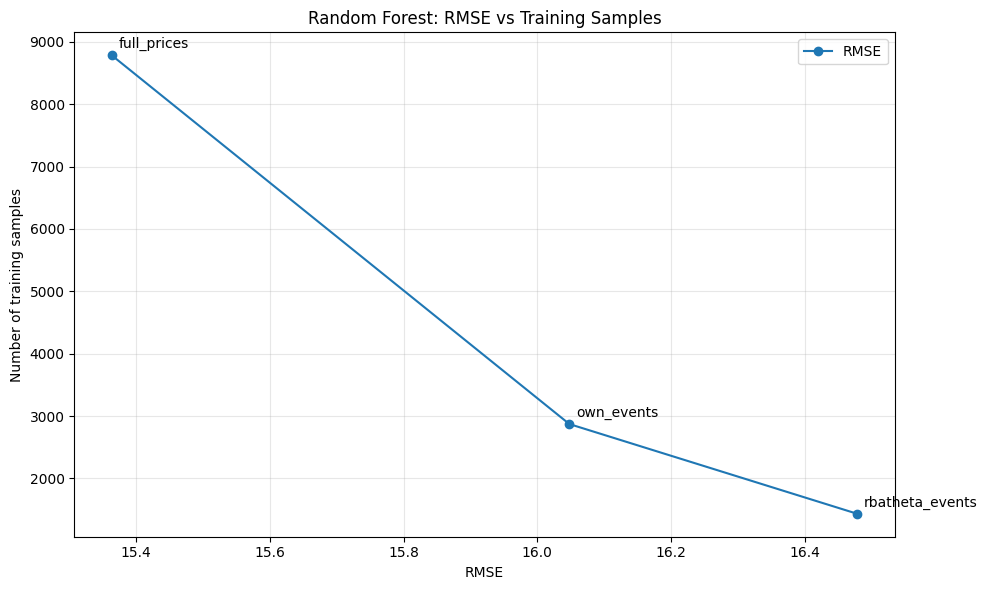

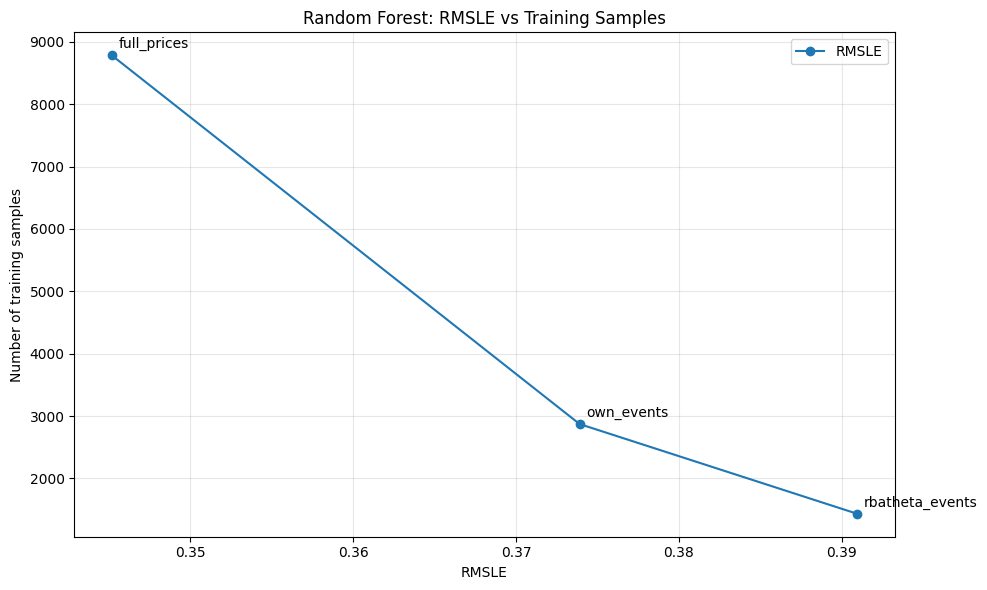

In [25]:
# ============================================================
# 17. RANDOM FOREST
# ============================================================

rf_results, rf_predictions = train_model_with_training_sets(
    model_name="Random Forest",
    model_factory=lambda: RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
)

rf_results_table = build_results_table(rf_results)

rf_results_table

plot_error_vs_training_samples(rf_results, metric="RMSE")
plot_error_vs_training_samples(rf_results, metric="RMSLE")

Model: Linear Regression
Training dataset: full_prices
n_train: 8783
n_test: 167
RMSE: 8.409988461607176
RMSLE: 0.11096368075229127

Model: Linear Regression
Training dataset: rbatheta_events
n_train: 1434
n_test: 167
RMSE: 8.692385322682561
RMSLE: 0.12518330227833482

Model: Linear Regression
Training dataset: own_events
n_train: 2872
n_test: 167
RMSE: 8.405830765590562
RMSLE: 0.11229143727534856



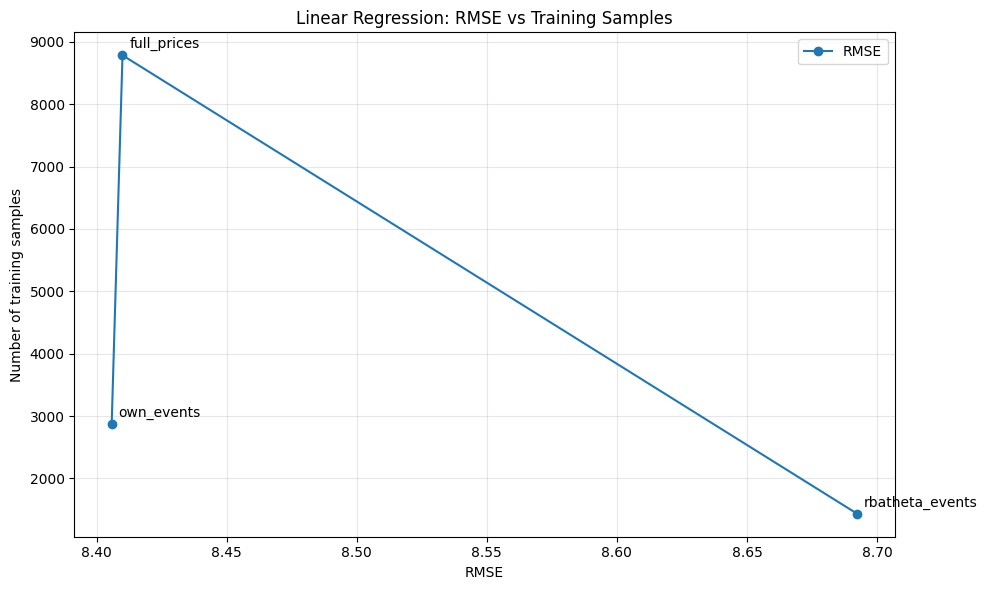

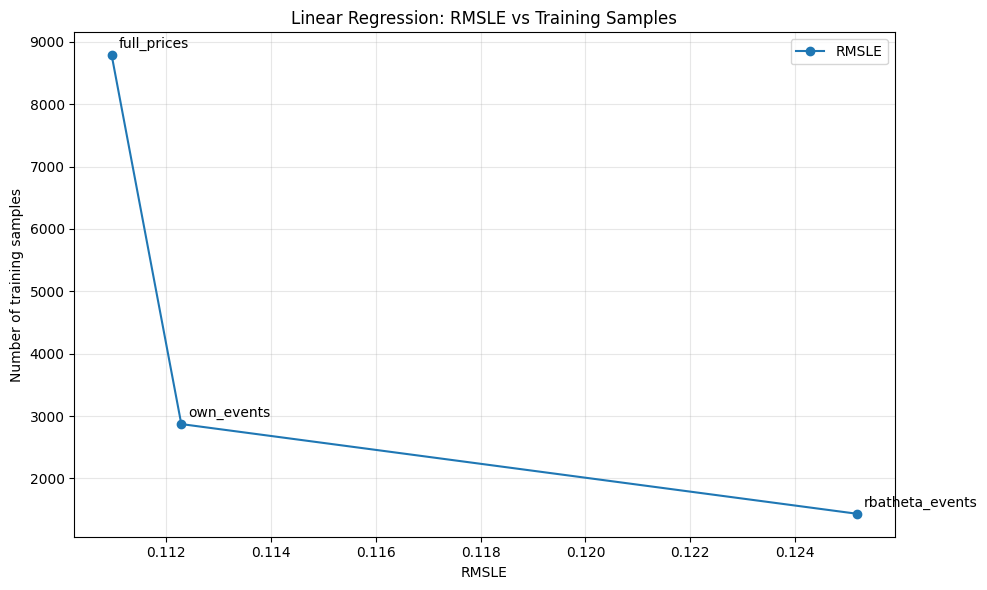

In [26]:
# ============================================================
# 18. LINEAR REGRESSION
# ============================================================

lr_results, lr_predictions = train_model_with_training_sets(
    model_name="Linear Regression",
    model_factory=lambda: LinearRegression()
)

lr_results_table = build_results_table(lr_results)

lr_results_table

plot_error_vs_training_samples(lr_results, metric="RMSE")
plot_error_vs_training_samples(lr_results, metric="RMSLE")

Model: Decision Tree
Training dataset: full_prices
n_train: 8783
n_test: 167
RMSE: 22.9513906144644
RMSLE: 0.5841704887933552

Model: Decision Tree
Training dataset: rbatheta_events
n_train: 1434
n_test: 167
RMSE: 21.61488684987581
RMSLE: 0.554346939561221

Model: Decision Tree
Training dataset: own_events
n_train: 2872
n_test: 167
RMSE: 22.37940698245214
RMSLE: 0.5782601785138296



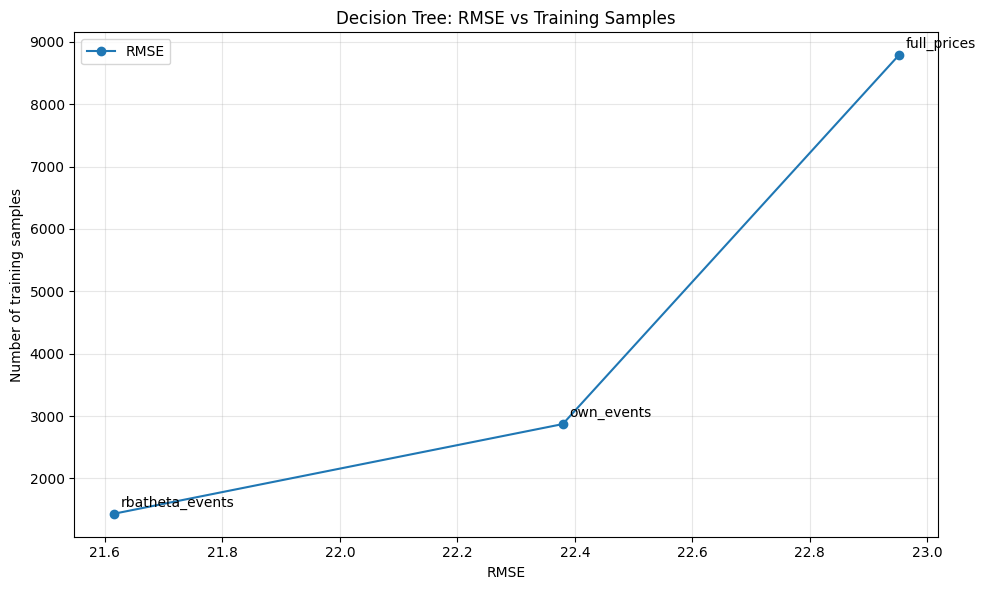

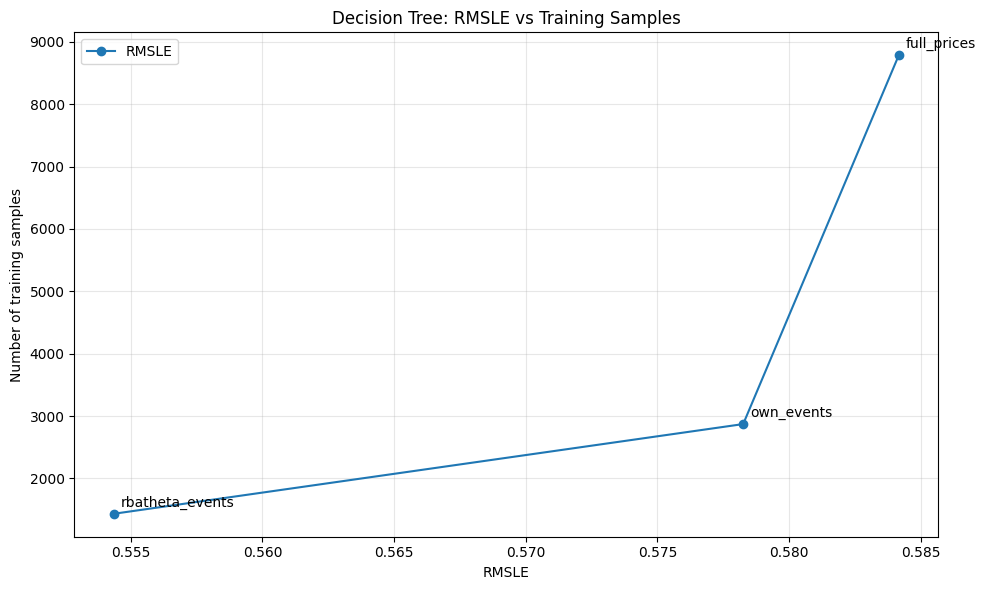

In [27]:
# ============================================================
# 19. DECISION TREE
# ============================================================

dt_results, dt_predictions = train_model_with_training_sets(
    model_name="Decision Tree",
    model_factory=lambda: DecisionTreeRegressor(
        random_state=42
    )
)

dt_results_table = build_results_table(dt_results)

dt_results_table

plot_error_vs_training_samples(dt_results, metric="RMSE")
plot_error_vs_training_samples(dt_results, metric="RMSLE")

Model: XGBoost
Training dataset: full_prices
n_train: 8783
n_test: 167
RMSE: 19.700872413488877
RMSLE: 0.4088894209884231

Model: XGBoost
Training dataset: rbatheta_events
n_train: 1434
n_test: 167
RMSE: 15.06076940686986
RMSLE: 0.3412063282477687

Model: XGBoost
Training dataset: own_events
n_train: 2872
n_test: 167
RMSE: 17.470538930229825
RMSLE: 0.33281177746303414



,Model,Training dataset,Training samples,Test samples,Train data used (%),RMSE,RMSLE,Data reduction (%)
1,XGBoost,rbatheta_events,1434,167,16.33,15.0608,0.3412,83.67
2,XGBoost,own_events,2872,167,32.70,17.4705,0.3328,67.30
0,XGBoost,full_prices,8783,167,100.00,19.7009,0.4089,0.00


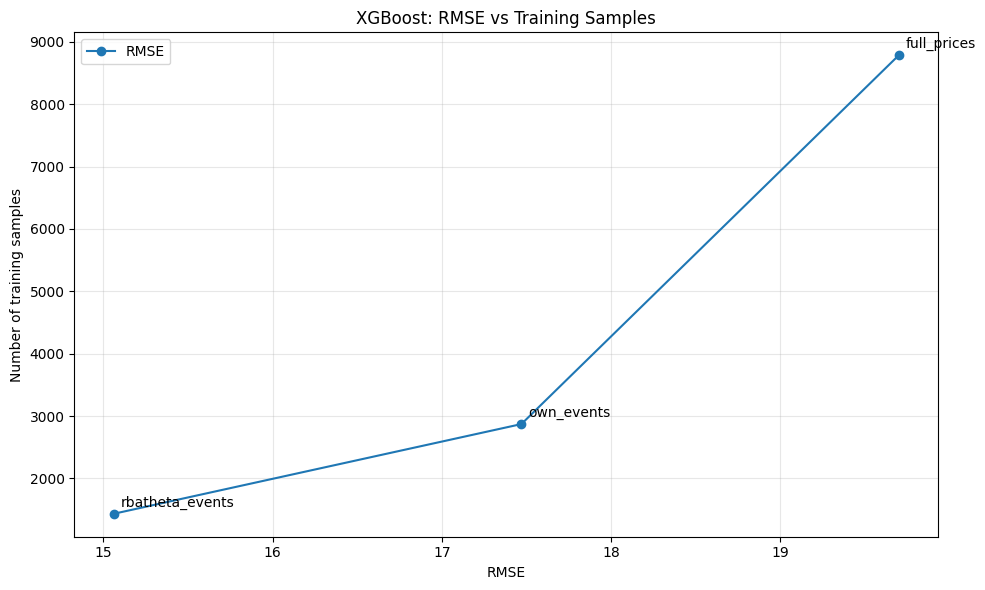

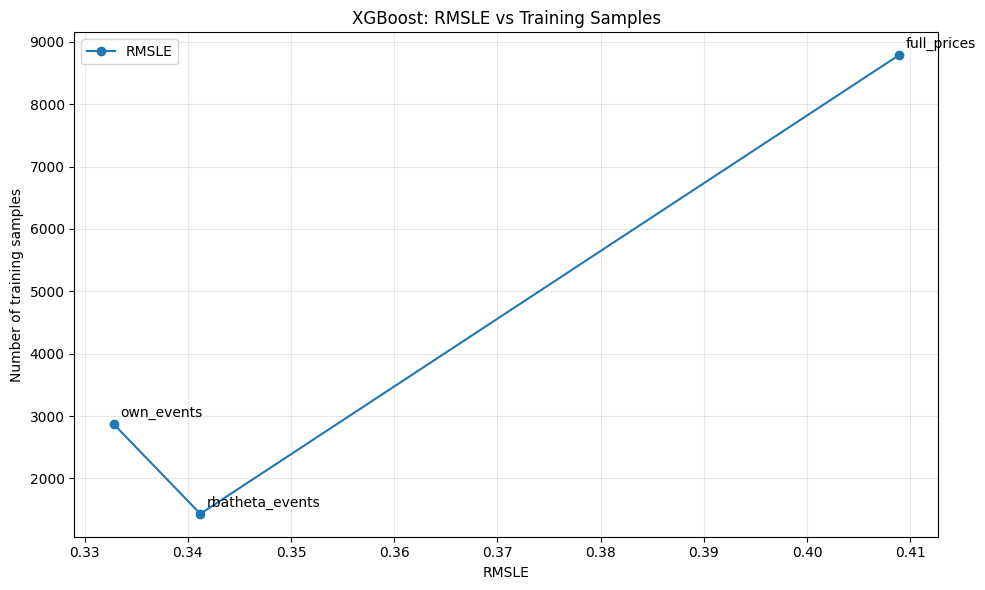

In [28]:
# ============================================================
# 20. XGBOOST
# ============================================================

xgb_results, xgb_predictions = train_model_with_training_sets(
    model_name="XGBoost",
    model_factory=lambda: XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
)

xgb_results_table = build_results_table(xgb_results)

display(xgb_results_table)

plot_error_vs_training_samples(xgb_results, metric="RMSE")
plot_error_vs_training_samples(xgb_results, metric="RMSLE")

In [29]:
# ============================================================
# 21. SUMMARY TABLE FOR ALL MODELS - CLEAN VERSION
# ============================================================

all_results_table = pd.concat(
    [
        rf_results_table,
        lr_results_table,
        dt_results_table,
        xgb_results_table,
    ],
    ignore_index=True
)

all_results_table = all_results_table[
    [
        "Model",
        "Training dataset",
        "Training samples",
        "Test samples",
        "Train data used (%)",
        "Data reduction (%)",
        "RMSE",
        "RMSLE",
    ]
]

all_results_table = all_results_table.sort_values(
    ["Model", "RMSE"],
    ascending=[True, True]
).reset_index(drop=True)

all_results_table

,Model,Training dataset,Training samples,Test samples,Train data used (%),Data reduction (%),RMSE,RMSLE
0,Decision Tree,rbatheta_events,1434,167,16.33,83.67,21.6149,0.5543
1,Decision Tree,own_events,2872,167,32.70,67.30,22.3794,0.5783
2,Decision Tree,full_prices,8783,167,100.00,0.00,22.9514,0.5842
3,Linear Regression,own_events,2872,167,32.70,67.30,8.4058,0.1123
4,Linear Regression,full_prices,8783,167,100.00,0.00,8.4100,0.1110
5,Linear Regression,rbatheta_events,1434,167,16.33,83.67,8.6924,0.1252
6,Random Forest,full_prices,8783,167,100.00,0.00,15.3635,0.3452
7,Random Forest,own_events,2872,167,32.70,67.30,16.0479,0.3739
8,Random Forest,rbatheta_events,1434,167,16.33,83.67,16.4784,0.3910
9,XGBoost,rbatheta_events,1434,167,16.33,83.67,15.0608,0.3412
